In [1]:
import os
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [2]:
TRAIN_DIR = r"C:\Users\KristianHaltenJensen\Noroff\Bachelor\archive (5)\data – Kopi\train"
VALID_DIR = r"C:\Users\KristianHaltenJensen\Noroff\Bachelor\archive (5)\data – Kopi\valid"
TEST_DIR = r"C:\Users\KristianHaltenJensen\Noroff\Bachelor\archive (5)\data – Kopi\test"

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_HEAD = 50
EPOCHS_FINE = 50
FINE_TUNE_AT = 120
LR_HEAD = 1e-4
LR_FINE = 1e-5

In [4]:


train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.25,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen  = ImageDataGenerator(preprocessing_function=preprocess_input)


In [5]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)


valid_generator = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 11132 images belonging to 12 classes.
Found 240 images belonging to 12 classes.
Found 600 images belonging to 12 classes.


In [6]:
num_classes = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())
print("Classes:", num_classes)
print(class_names)

with open("class_names.json", "w", encoding="utf-8") as f:
    json.dump(class_names, f, indent=2)

Classes: 12
['Black Rust', 'Blast', 'Brown Rust', 'Common Root Rot', 'Fusarium Head Blight', 'Healthy', 'Leaf Blight', 'Mildew', 'Septoria', 'Smut', 'Tan spot', 'Yellow Rust']


In [7]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
)
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x) 
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 2048)                │           8,192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 12)                  │          24,588 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,620,492 (90.11 MB)

 Trainable params: 28,684 (112.05 KB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [ ]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        "ResNet50_WPD.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_HEAD),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


history_head = model.fit(
    train_generator,
    epochs=EPOCHS_HEAD,
    validation_data=valid_generator,
    callbacks = callbacks
)


C:\Users\KristianHaltenJensen\anaconda4\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 739s 2s/step - accuracy: 0.1734 - loss: 3.2454 - val_accuracy: 0.4292 - val_loss: 2.0073
Epoch 2/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 548s 2s/step - accuracy: 0.4473 - loss: 1.9046 - val_accuracy: 0.5083 - val_loss: 1.9050
Epoch 3/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 454s 1s/step - accuracy: 0.5309 - loss: 1.6034 - val_accuracy: 0.5667 - val_loss: 1.7784
Epoch 4/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 441s 1s/step - accuracy: 0.5961 - loss: 1.3556 - val_accuracy: 0.5750 - val_loss: 1.7079
Epoch 5/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 434s 1s/step - accuracy: 0.6119 - loss: 1.2731 - val_accuracy: 0.6125 - val_loss: 1.6075
Epoch 6/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 429s 1s/step - accuracy: 0.6238 - loss: 1.2148 - val_accuracy: 0.6250 - val_loss: 1.5819
Epoch 7/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 436s 1s/step - accuracy: 0.6512 - loss: 1.1447 - val_accuracy: 0.6167 - val_loss: 1.5150
Epoch 8/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 426s 1s/step - accuracy: 0.6526 - loss: 1.1099 - val_accu

In [9]:
base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = model.fit(
    train_generator,
    epochs=EPOCHS_FINE,
    validation_data=valid_generator,
    callbacks = callbacks
)

Epoch 1/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 699s 2s/step - accuracy: 0.7356 - loss: 0.8002 - val_accuracy: 0.7417 - val_loss: 1.2376
Epoch 2/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 656s 2s/step - accuracy: 0.7750 - loss: 0.6809 - val_accuracy: 0.7583 - val_loss: 1.1984
Epoch 3/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 1334s 4s/step - accuracy: 0.7848 - loss: 0.6287 - val_accuracy: 0.7750 - val_loss: 1.1334
Epoch 4/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 1331s 4s/step - accuracy: 0.8093 - loss: 0.5491 - val_accuracy: 0.7917 - val_loss: 1.1498
Epoch 5/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 1326s 4s/step - accuracy: 0.8231 - loss: 0.5226 - val_accuracy: 0.8167 - val_loss: 1.0548
Epoch 6/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 1320s 4s/step - accuracy: 0.8305 - loss: 0.5048 - val_accuracy: 0.8250 - val_loss: 1.0231
Epoch 7/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 1318s 4s/step - accuracy: 0.8475 - loss: 0.4387 - val_accuracy: 0.8417 - val_loss: 1.0102
Epoch 8/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 1113s 3s/step - accuracy: 0.8598 - loss: 0.4005 - va

In [10]:
model.save('ResNet50_WPD.keras')

In [11]:
with open("training_history_ResNet50_2.json", "w", encoding="utf-8") as f:
    json.dump(history_head.history, f, indent=2)

print("Saved: training_history_ResNet50_2.json")

Saved: training_history_ResNet50_2.json


In [14]:
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.8915 - loss: 1.0609
Test loss: 1.2454
Test accuracy: 0.8967


In [15]:
test_metrics = {
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy)
}

with open("test_metric_ResNet50_2.json", "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, indent=2)


Saved test_metrics_ResNet50_2.json


In [16]:
import numpy as np

y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

19/19 ━━━━━━━━━━━━━━━━━━━━ 21s 911ms/step


In [17]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))


                           precision    recall  f1-score   support

          black_rust_test       1.00      0.82      0.90        50
               blast_test       0.96      1.00      0.98        50
          brown_rust_test       0.84      0.98      0.91        50
     common_root_rot_test       1.00      1.00      1.00        50
fusarium_head_blight_test       1.00      1.00      1.00        50
             healthy_test       0.71      0.10      0.18        50
         leaf_blight_test       0.96      0.96      0.96        50
              mildew_test       1.00      0.96      0.98        50
            septoria_test       1.00      1.00      1.00        50
                smut_test       1.00      0.98      0.99        50
            tan_spot_test       0.94      0.96      0.95        50
         yellow_rust_test       0.53      1.00      0.69        50

                 accuracy                           0.90       600
                macro avg       0.91      0.90      0.88    

In [29]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=class_names,      # True labels (rows)
    columns=class_names     # Predicted labels (columns)
)

print(cm_df)


                           black_rust_test  blast_test  brown_rust_test  \
black_rust_test                         44           0                6   
blast_test                               0          50                0   
brown_rust_test                          0           0               48   
common_root_rot_test                     0           0                0   
fusarium_head_blight_test                0           0                0   
healthy_test                             1           2                0   
leaf_blight_test                         0           0                0   
mildew_test                              0           0                0   
septoria_test                            0           0                0   
smut_test                                0           0                0   
tan_spot_test                            0           0                0   
yellow_rust_test                         0           0                0   

                        

In [30]:
cm_df

,black_rust_test,blast_test,brown_rust_test,common_root_rot_test,fusarium_head_blight_test,healthy_test,leaf_blight_test,mildew_test,septoria_test,smut_test,tan_spot_test,yellow_rust_test
black_rust_test,44,0,6,0,0,0,0,0,0,0,0,0
blast_test,0,50,0,0,0,0,0,0,0,0,0,0
brown_rust_test,0,0,48,0,0,0,0,0,0,0,0,2
common_root_rot_test,0,0,0,50,0,0,0,0,0,0,0,0
fusarium_head_blight_test,0,0,0,0,50,0,0,0,0,0,0,0
healthy_test,1,2,0,0,0,4,0,0,0,0,0,43
leaf_blight_test,0,0,0,0,0,0,49,0,0,0,1,0
mildew_test,0,0,0,0,0,0,0,50,0,0,0,0
septoria_test,0,0,0,0,0,0,3,0,47,0,0,0
smut_test,0,0,0,0,0,0,0,0,0,50,0,0


In [31]:
cm_df.to_csv("confusion_matrix_ResNet50.csv")
print("Saved confusion_matrix_ResNet50.csv")

Saved confusion_matrix_ResNet50.csv


Loaded model.
Top-level layers:
0 input_layer_5 InputLayer
1 resnet50 Functional
2 global_average_pooling2d_2 GlobalAveragePooling2D
3 dropout_2 Dropout
4 dense Dense
Backbone: resnet50
Using last conv layer: conv5_block3_out

Image: C:\Users\KristianHaltenJensen\Noroff\Bachelor\Images\leaf rust.jpg
Predicted class: Tan spot
Confidence: 0.3336 (33.36%)

Top 5 predictions:
  Tan spot                  0.3336 (33.36%)
  Healthy                   0.2019 (20.19%)
  Brown Rust                0.1867 (18.67%)
  Leaf Blight               0.1389 (13.89%)
  Black Rust                0.0750 (7.50%)

Image: C:\Users\KristianHaltenJensen\Noroff\Bachelor\Images\Healthy leaf.jpg
Predicted class: Healthy
Confidence: 1.0000 (100.00%)

Top 5 predictions:
  Healthy                   1.0000 (100.00%)
  Mildew                    0.0000 (0.00%)
  Black Rust                0.0000 (0.00%)
  Tan spot                  0.0000 (0.00%)
  Brown Rust                0.0000 (0.00%)

Image: C:\Users\KristianHaltenJensen

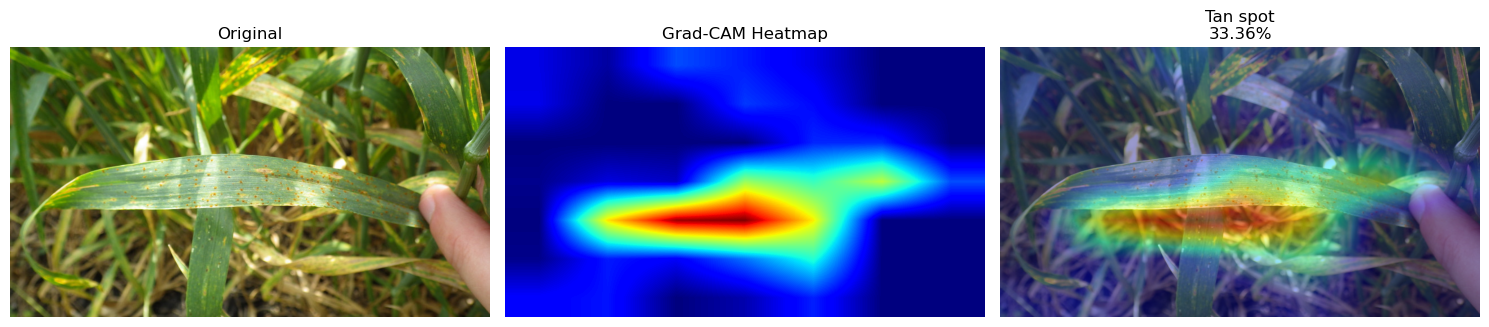

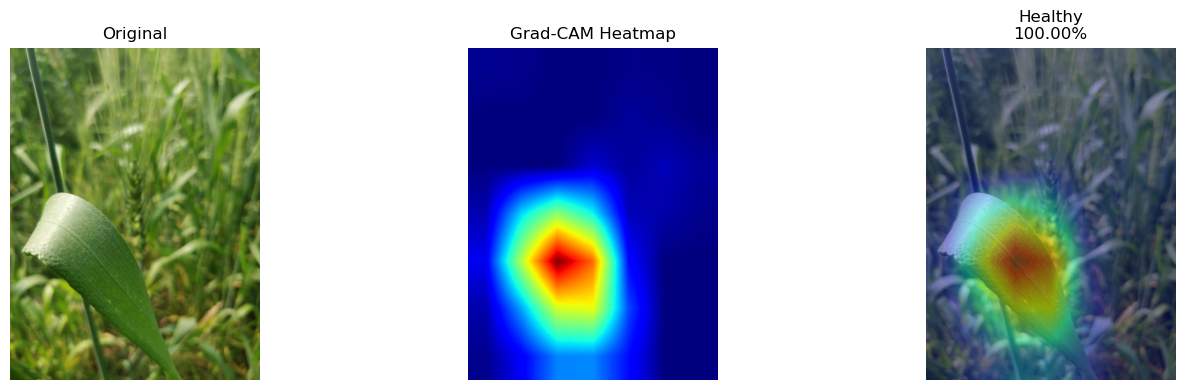

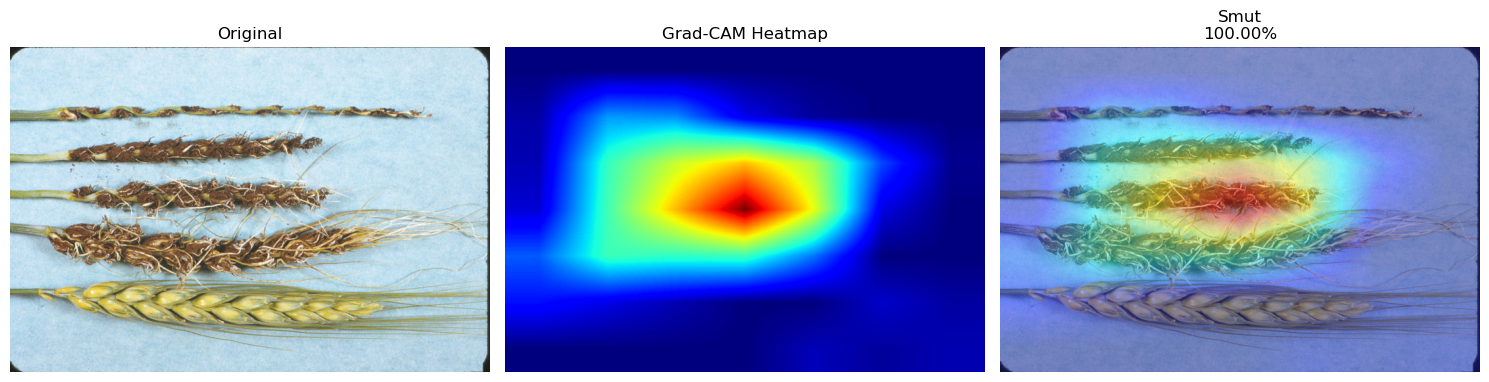

In [2]:
import os
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image

# =========================
# PATHS
# =========================
MODEL_PATH = "WheatDiseaseDetection_ResNet50.keras"
CLASS_JSON = "class_names.json"



IMAGE_PATHS = [
    r"C:\Users\KristianHaltenJensen\Noroff\Bachelor\Images\leaf rust.jpg",
    r"C:\Users\KristianHaltenJensen\Noroff\Bachelor\Images\Healthy leaf.jpg",
    r"C:\Users\KristianHaltenJensen\Noroff\Bachelor\Images\wheat loose smut.jpg",
]

IMG_SIZE = (224, 224)

# =========================
# LOAD MODEL
# =========================
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

with open(CLASS_JSON, "r", encoding="utf-8") as f:
    class_names = json.load(f)

print("Loaded model.")
print("Top-level layers:")
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.__class__.__name__)

# Get the nested ResNet50 backbone
base_model = model.get_layer("resnet50")
last_conv_layer_name = "conv5_block3_out"   # best choice for ResNet50

print("Backbone:", base_model.name)
print("Using last conv layer:", last_conv_layer_name)

# =========================
# PREPROCESS
# =========================
def load_and_preprocess_image(img_path, target_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img_array

# =========================
# GRAD-CAM FOR NESTED RESNET50
# =========================
def make_gradcam_heatmap(img_array, model, base_model, pred_index=None):
    # Get the classifier head layers from the full model
    gap_layer = model.get_layer("global_average_pooling2d_2")
    dropout_layer = model.get_layer("dropout_2")
    classifier_layer = model.get_layer("dense")

    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    with tf.GradientTape() as tape:
        # Forward pass through ResNet50 backbone only
        conv_outputs = base_model(img_tensor, training=False)   # shape: (1, 7, 7, 2048)
        tape.watch(conv_outputs)

        # Forward pass through your classifier head manually
        x = gap_layer(conv_outputs)
        x = dropout_layer(x, training=False)
        preds = classifier_layer(x)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])

        class_score = preds[:, pred_index]

    # Gradient of predicted class score wrt conv feature map
    grads = tape.gradient(class_score, conv_outputs)

    conv_outputs = conv_outputs[0]   # (7, 7, 2048)
    grads = grads[0]                 # (7, 7, 2048)

    # Channel importance weights
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))  # (2048,)

    # Weighted sum of channels
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)  # (7, 7)

    # ReLU + normalize
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()
# =========================
# OVERLAY
# =========================
def overlay_heatmap(img_path, heatmap, alpha=0.4):
    original_bgr = cv2.imread(img_path)
    original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)

    heatmap_resized = cv2.resize(heatmap, (original_rgb.shape[1], original_rgb.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(original_rgb, 1 - alpha, heatmap_color, alpha, 0)
    return original_rgb, heatmap_resized, overlay

# =========================
# RUN ON 3 IMAGES
# =========================
results = []

for img_path in IMAGE_PATHS:
    print("\n" + "=" * 70)
    print("Image:", img_path)

    img_array = load_and_preprocess_image(img_path)
    preds = model.predict(img_array, verbose=0)[0]

    pred_idx = int(np.argmax(preds))
    pred_class = class_names[pred_idx]
    confidence = float(preds[pred_idx])

    sorted_probs = sorted(zip(class_names, preds), key=lambda x: x[1], reverse=True)

    print("Predicted class:", pred_class)
    print(f"Confidence: {confidence:.4f} ({confidence*100:.2f}%)")
    print("\nTop 5 predictions:")
    for cls, prob in sorted_probs[:5]:
        print(f"  {cls:25s} {prob:.4f} ({prob*100:.2f}%)")

    heatmap = make_gradcam_heatmap(
        img_array=img_array,
        model=model,
        base_model=base_model,
        pred_index=pred_idx
    )


    original_rgb, heatmap_resized, overlay = overlay_heatmap(img_path, heatmap)

    results.append({
        "img_path": img_path,
        "pred_class": pred_class,
        "confidence": confidence,
        "probs": sorted_probs,
        "original": original_rgb,
        "heatmap": heatmap_resized,
        "overlay": overlay
    })

# =========================
# SHOW RESULTS
# =========================
for r in results:
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(r["original"])
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(r["heatmap"], cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(r["overlay"])
    plt.title(f'{r["pred_class"]}\n{r["confidence"]*100:.2f}%')
    plt.axis("off")

    plt.tight_layout()
    plt.show()